# Mathematical Distribution & Equation Discovery for S11

## Objective

Given the dataset:

- **Inputs:** `L`, `W`, `F`
- **Output:** `S11`

the objective is **not** to use conventional prediction algorithms such as Linear Regression, Random Forest, XGBoost, etc.

Instead, this notebook follows a **mathematical discovery approach**:

\[
S_{11}=f(L,W,F)
\]

We first study the distribution and structure of the data, then identify transformations and functional forms that can lead to a compact mathematical equation.

### Workflow

1. Load and validate the dataset
2. Exploratory distribution analysis
3. Study S11 probability distribution
4. Analyze S11 against L, W and F
5. Investigate the 26×26 parameter-grid structure
6. Search for dimensionless/geometrical variables
7. Test candidate mathematical functions
8. Select a compact equation using goodness-of-fit and residual analysis
9. Validate the final mathematical equation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.optimize import curve_fit
from pathlib import Path

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

DATA_PATH = Path("L_W_variables.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())


Dataset shape: (676, 5)
Columns: ['S.No', 'L', 'W', 'F', 'S11']


,S.No,L,W,F,S11
0,1,16.24,22.66,4.24,-17.358022
1,2,16.64,22.66,4.14,-17.071609
2,3,17.04,22.66,4.06,-16.999123
3,4,17.44,22.66,3.99,-16.791115
4,5,17.84,22.66,3.90,-16.537894


## 1. Data validation

In [2]:
required_columns = ["L", "W", "F", "S11"]

missing_columns = [c for c in required_columns if c not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("Missing values:")
display(df[required_columns].isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
display(df[required_columns].dtypes)

print("\nDescriptive statistics:")
display(df[required_columns].describe())


Missing values:


L      0
W      0
F      0
S11    0
dtype: int64


Duplicate rows: 0

Data types:


L      float64
W      float64
F      float64
S11    float64
dtype: object


Descriptive statistics:


,L,W,F,S11
count,676.000000,676.000000,676.000000,676.000000
mean,21.240000,27.660000,3.794438,-17.564635
std,3.002221,3.002221,0.647017,9.606007
min,16.240000,22.660000,2.650000,-58.263072
25%,18.640000,25.060000,3.327500,-23.906591
50%,21.240000,27.660000,3.730000,-17.360892
75%,23.840000,30.260000,4.340000,-8.774893
max,26.240000,32.660000,5.000000,-4.424953


## 2. Distribution analysis of S11

We first investigate the output itself:

\[
P(S_{11})
\]

This is only the first stage. A good fit to the marginal distribution of S11 does **not** by itself explain the dependence on L, W and F.


S11 mean     : -17.564634907318048
S11 median   : -17.360892105
S11 std      : 9.606007195907297
S11 minimum  : -58.26307211
S11 maximum  : -4.42495316
S11 skewness : -0.3790791064033641
S11 kurtosis : -0.40970341871855753


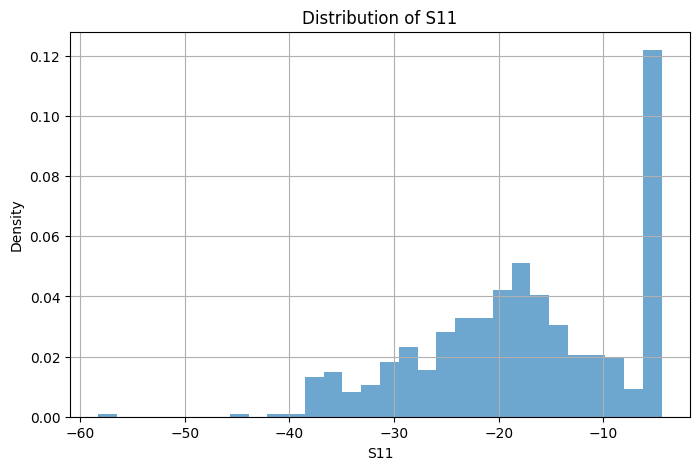

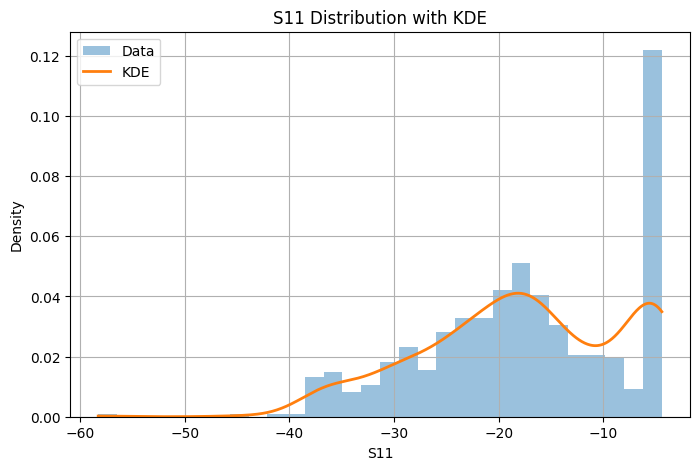

In [3]:
s11 = df["S11"].to_numpy()

print("S11 mean     :", np.mean(s11))
print("S11 median   :", np.median(s11))
print("S11 std      :", np.std(s11, ddof=1))
print("S11 minimum  :", np.min(s11))
print("S11 maximum  :", np.max(s11))
print("S11 skewness :", stats.skew(s11))
print("S11 kurtosis :", stats.kurtosis(s11))

fig, ax = plt.subplots()
ax.hist(s11, bins=30, density=True, alpha=0.65)
ax.set_xlabel("S11")
ax.set_ylabel("Density")
ax.set_title("Distribution of S11")
plt.show()

kde = stats.gaussian_kde(s11)
x = np.linspace(s11.min(), s11.max(), 600)

fig, ax = plt.subplots()
ax.hist(s11, bins=30, density=True, alpha=0.45, label="Data")
ax.plot(x, kde(x), linewidth=2, label="KDE")
ax.set_xlabel("S11")
ax.set_ylabel("Density")
ax.set_title("S11 Distribution with KDE")
ax.legend()
plt.show()


## 3. Candidate probability distributions for S11

Because S11 is negative, we also inspect the positive magnitude:

\[
Y=-S_{11}
\]

We compare several standard distributions only as a **descriptive distribution study**. This is not the final mathematical model.

The comparison uses AIC; lower AIC is better among models fitted to the same data.


In [4]:
y_mag = -s11

candidate_distributions = {
    "normal": stats.norm,
    "lognormal": stats.lognorm,
    "gamma": stats.gamma,
    "weibull": stats.weibull_min,
    "exponential": stats.expon,
}

distribution_results = []

for name, dist in candidate_distributions.items():
    try:
        if name == "lognormal":
            params = dist.fit(y_mag, floc=0)
        elif name in ["gamma", "weibull", "exponential"]:
            params = dist.fit(y_mag, floc=0)
        else:
            params = dist.fit(y_mag)

        log_likelihood = np.sum(dist.logpdf(y_mag, *params))
        k = len(params)
        aic = 2 * k - 2 * log_likelihood

        distribution_results.append({
            "Distribution": name,
            "AIC": aic,
            "LogLikelihood": log_likelihood
        })
    except Exception as e:
        print(name, "failed:", e)

dist_results = pd.DataFrame(distribution_results).sort_values("AIC")
display(dist_results)


,Distribution,AIC,LogLikelihood
3,weibull,4900.311471,-2447.155736
2,gamma,4923.471713,-2458.735856
0,normal,4980.153614,-2488.076807
1,lognormal,4981.889847,-2487.944923
4,exponential,5230.679900,-2613.339950


## 4. Relationship of S11 with each original variable

We now move from the marginal distribution toward:

\[
S_{11}=f(L,W,F)
\]


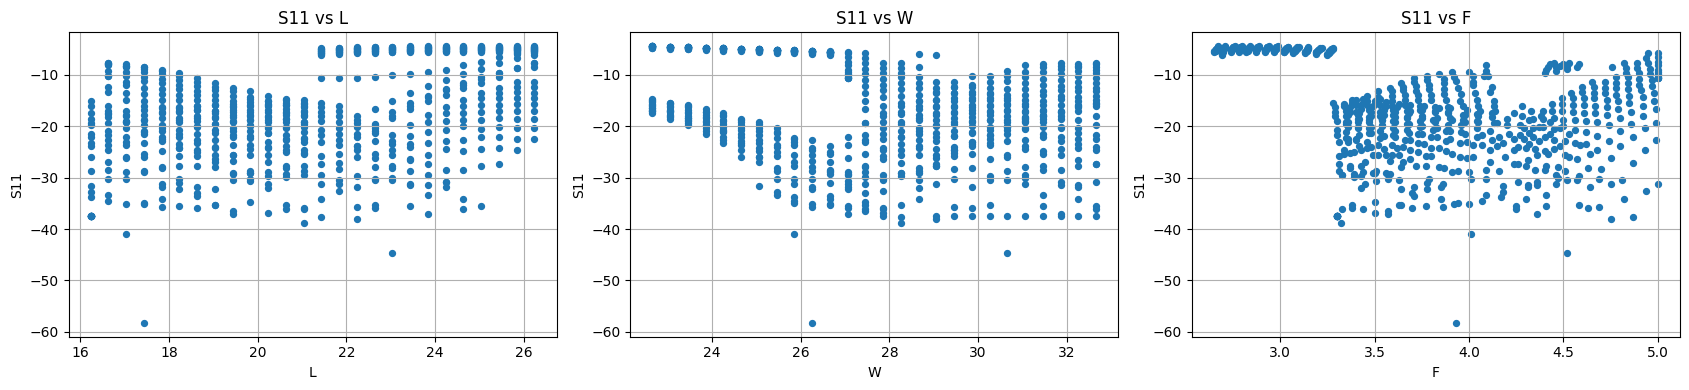

Correlation matrix:


,L,W,F,S11
L,1.000000e+00,-2.960595e-16,-0.027072,0.402835
W,-2.960595e-16,1.000000e+00,0.456102,-0.305357
F,-2.707182e-02,4.561025e-01,1.000000,-0.346635
S11,4.028346e-01,-3.053567e-01,-0.346635,1.000000


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

for ax, feature in zip(axes, ["L", "W", "F"]):
    ax.scatter(df[feature], df["S11"], s=18)
    ax.set_xlabel(feature)
    ax.set_ylabel("S11")
    ax.set_title(f"S11 vs {feature}")

plt.tight_layout()
plt.show()

print("Correlation matrix:")
display(df[["L", "W", "F", "S11"]].corr())


## 5. Check the parameter-grid structure

There are 26 unique values of L and 26 unique values of W.

This means:

\[
26	imes26=676
\]

which exactly matches the number of rows.

This strongly suggests that the dataset represents a structured parameter sweep rather than independent random observations.


In [6]:
print("Unique L values:", df["L"].nunique())
print("Unique W values:", df["W"].nunique())
print("Unique F values:", df["F"].nunique())
print("26 × 26 =", 26 * 26)

# Confirm whether every (L,W) combination occurs exactly once
lw_counts = df.groupby(["L", "W"]).size()

print("\nNumber of unique (L,W) pairs:", len(lw_counts))
print("Maximum observations per (L,W) pair:", lw_counts.max())
print("Minimum observations per (L,W) pair:", lw_counts.min())

if len(lw_counts) == 26 * 26 and lw_counts.max() == 1:
    print("Confirmed: complete 26 × 26 L-W grid.")
else:
    print("The L-W combinations are not a complete one-observation-per-cell grid.")


Unique L values: 26
Unique W values: 26
Unique F values: 209
26 × 26 = 676

Number of unique (L,W) pairs: 676
Maximum observations per (L,W) pair: 1
Minimum observations per (L,W) pair: 1
Confirmed: complete 26 × 26 L-W grid.


## 6. Heatmaps of F and S11 over the L-W parameter space

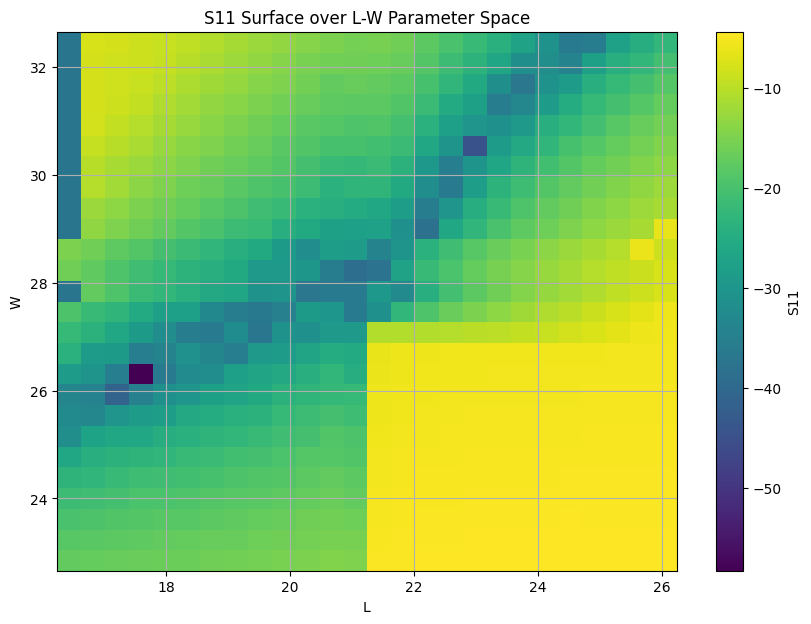

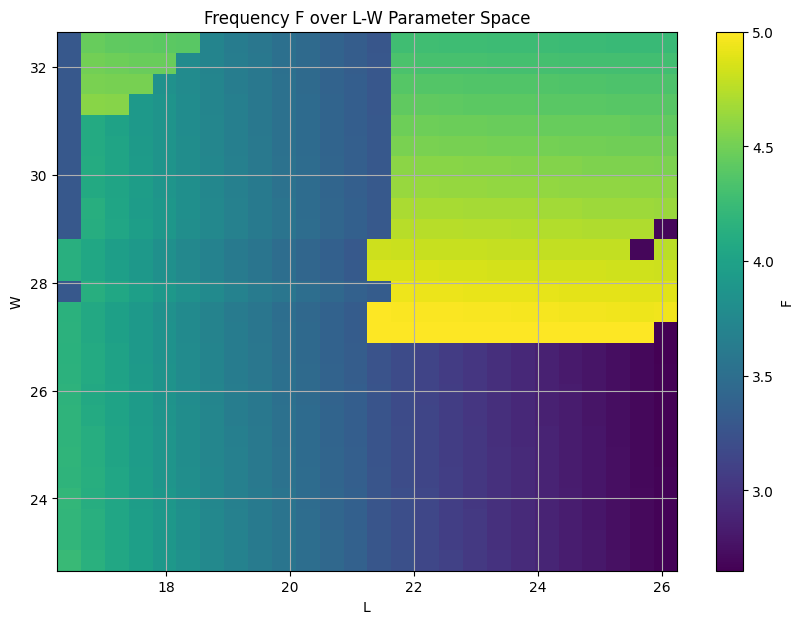

In [7]:
f_grid = df.pivot(index="W", columns="L", values="F").sort_index()
s11_grid = df.pivot(index="W", columns="L", values="S11").sort_index()

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(
    s11_grid.values,
    aspect="auto",
    origin="lower",
    extent=[
        s11_grid.columns.min(), s11_grid.columns.max(),
        s11_grid.index.min(), s11_grid.index.max()
    ]
)
ax.set_xlabel("L")
ax.set_ylabel("W")
ax.set_title("S11 Surface over L-W Parameter Space")
plt.colorbar(im, ax=ax, label="S11")
plt.show()

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(
    f_grid.values,
    aspect="auto",
    origin="lower",
    extent=[
        f_grid.columns.min(), f_grid.columns.max(),
        f_grid.index.min(), f_grid.index.max()
    ]
)
ax.set_xlabel("L")
ax.set_ylabel("W")
ax.set_title("Frequency F over L-W Parameter Space")
plt.colorbar(im, ax=ax, label="F")
plt.show()


## 7. Inspect S11 curves along L and W

Instead of immediately fitting a global equation, we inspect whether the response has a recognizable curve shape.

For fixed W:

\[
S_{11}=f(L\mid W)
\]

For fixed L:

\[
S_{11}=f(W\mid L)
\]

This helps us identify whether a separable, power-law, exponential, reciprocal, polynomial, or other functional form is plausible.


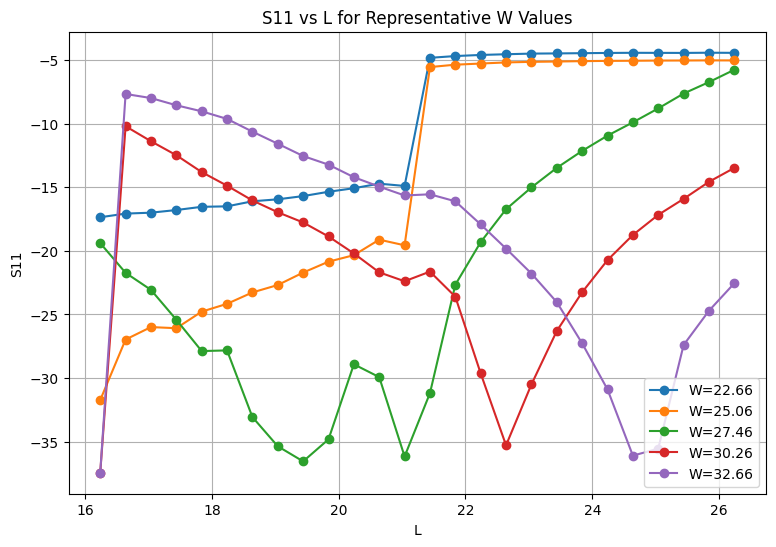

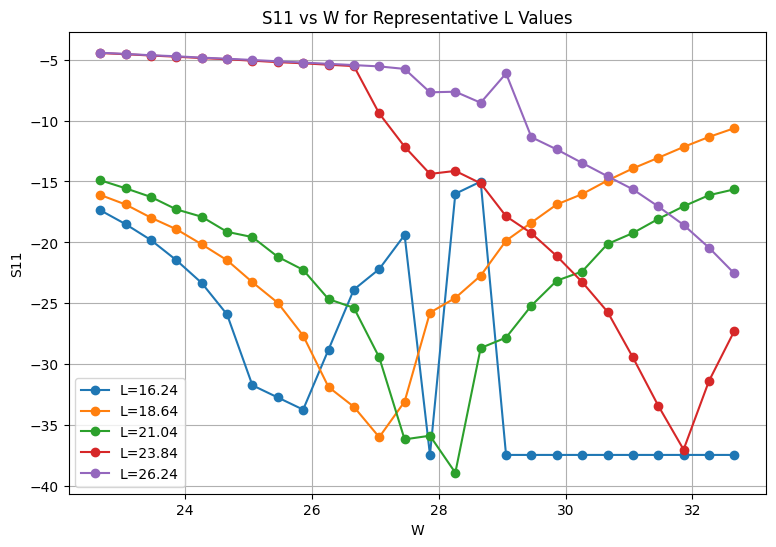

In [8]:
# Select representative W values
w_values = np.linspace(df["W"].min(), df["W"].max(), 5)
w_selected = df["W"].iloc[(np.abs(df["W"].to_numpy()[:, None] - w_values)).argmin(axis=0)].unique()

fig, ax = plt.subplots(figsize=(9, 6))

for w in sorted(w_selected):
    subset = df[np.isclose(df["W"], w)]
    subset = subset.sort_values("L")
    ax.plot(subset["L"], subset["S11"], marker="o", label=f"W={w:.2f}")

ax.set_xlabel("L")
ax.set_ylabel("S11")
ax.set_title("S11 vs L for Representative W Values")
ax.legend()
plt.show()

# Select representative L values
l_values = np.linspace(df["L"].min(), df["L"].max(), 5)
l_selected = df["L"].iloc[(np.abs(df["L"].to_numpy()[:, None] - l_values)).argmin(axis=0)].unique()

fig, ax = plt.subplots(figsize=(9, 6))

for l in sorted(l_selected):
    subset = df[np.isclose(df["L"], l)]
    subset = subset.sort_values("W")
    ax.plot(subset["W"], subset["S11"], marker="o", label=f"L={l:.2f}")

ax.set_xlabel("W")
ax.set_ylabel("S11")
ax.set_title("S11 vs W for Representative L Values")
ax.legend()
plt.show()


## 8. Dimensionless and transformed variables

A key mathematical-discovery idea is to search for variables that describe the geometry more naturally than L and W independently.

We investigate:

\[
r=

rac{W}{L},\qquad
q=

rac{L}{W},\qquad
p=LW
\]

and frequency-related transformations such as:

\[
F,\quad 

rac{1}{F},\quad \log(F)
\]

These are candidate descriptors, not assumptions about the final equation.


In [9]:
work = df.copy()

work["W_over_L"] = work["W"] / work["L"]
work["L_over_W"] = work["L"] / work["W"]
work["L_times_W"] = work["L"] * work["W"]
work["inv_F"] = 1.0 / work["F"]
work["log_F"] = np.log(work["F"])
work["sqrt_F"] = np.sqrt(work["F"])
work["F_squared"] = work["F"] ** 2

candidate_features = [
    "L", "W", "F",
    "W_over_L", "L_over_W", "L_times_W",
    "inv_F", "log_F", "sqrt_F", "F_squared"
]

corr_table = work[candidate_features + ["S11"]].corr()["S11"].sort_values(
    key=lambda x: np.abs(x), ascending=False
)

display(corr_table.to_frame("Correlation with S11"))


,Correlation with S11
S11,1.000000
L_over_W,0.551391
W_over_L,-0.452034
inv_F,0.429126
L,0.402835
log_F,-0.389491
sqrt_F,-0.368337
F,-0.346635
W,-0.305357
F_squared,-0.302630


## 9. First mathematical candidate: separable power-law structure

A useful hypothesis to test is:

\[
|S_{11}|=A\,L^aW^bF^c
\]

Taking logarithms gives:

\[
\ln |S_{11}|=
\ln A+a\ln L+b\ln W+c\ln F
\]

This is used here as a **mathematical transformation for equation discovery**, not as a conventional machine-learning model.

The resulting coefficients give us a first indication of whether a power-law structure is supported by the data.


In [10]:
positive_mag = -df["S11"]

# A logarithm requires positive magnitude; all -S11 values are positive here.
Z = np.column_stack([
    np.ones(len(df)),
    np.log(df["L"]),
    np.log(df["W"]),
    np.log(df["F"])
])

target_log = np.log(positive_mag)

coefficients, *_ = np.linalg.lstsq(Z, target_log, rcond=None)

log_A, a, b, c = coefficients
A = np.exp(log_A)

pred_mag = A * df["L"]**a * df["W"]**b * df["F"]**c
pred_s11 = -pred_mag

def regression_metrics(y_true, y_pred):
    residual = y_true - y_pred
    mse = np.mean(residual**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(residual))
    ss_res = np.sum(residual**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - ss_res / ss_tot
    return r2, rmse, mae

r2, rmse, mae = regression_metrics(df["S11"].to_numpy(), pred_s11.to_numpy())

print("Candidate power-law equation:")
print(f"|S11| = {A:.8g} * L^({a:.8g}) * W^({b:.8g}) * F^({c:.8g})")
print(f"S11 = -{A:.8g} * L^({a:.8g}) * W^({b:.8g}) * F^({c:.8g})")

print("\nInitial fit metrics:")
print("R²   :", r2)
print("RMSE :", rmse)
print("MAE  :", mae)


Candidate power-law equation:
|S11| = 8.5865975 * L^(-1.8843696) * W^(1.320236) * F^(1.4347289)
S11 = -8.5865975 * L^(-1.8843696) * W^(1.320236) * F^(1.4347289)

Initial fit metrics:
R²   : 0.11567104819027496
RMSE : 9.026686672680245
MAE  : 6.681958760915638


## 10. Residual analysis of the candidate equation

A mathematical equation is not accepted just because its R² is high.

We inspect:

\[
e_i=S_{11,i}-\hat S_{11,i}
\]

A useful equation should produce residuals that are relatively small and should not show strong systematic structure.


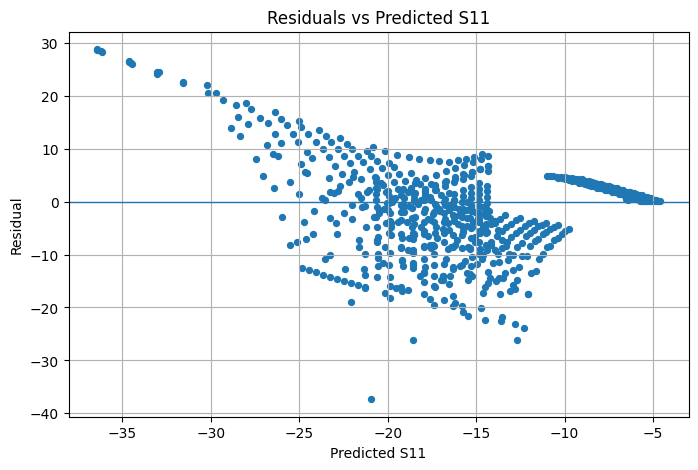

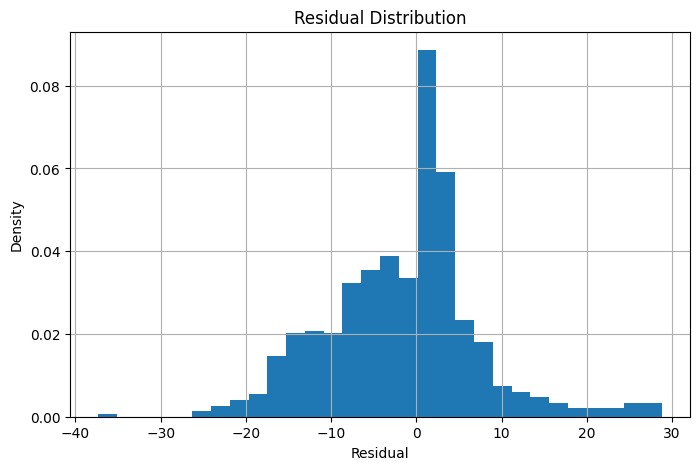

Residual mean: -1.6285093180072618
Residual std : 8.885145662035736


In [11]:
residuals = df["S11"].to_numpy() - pred_s11.to_numpy()

fig, ax = plt.subplots()
ax.scatter(pred_s11, residuals, s=18)
ax.axhline(0, linewidth=1)
ax.set_xlabel("Predicted S11")
ax.set_ylabel("Residual")
ax.set_title("Residuals vs Predicted S11")
plt.show()

fig, ax = plt.subplots()
ax.hist(residuals, bins=30, density=True)
ax.set_xlabel("Residual")
ax.set_ylabel("Density")
ax.set_title("Residual Distribution")
plt.show()

print("Residual mean:", residuals.mean())
print("Residual std :", residuals.std(ddof=1))


# Next research stage

The notebook intentionally stops after the **first structural candidate**.

The next stage is the important discovery stage:

### Candidate mathematical families to test

1. Power-law:
   \[
   S_{11}=A L^a W^b F^c
   \]

2. Reciprocal/power-law:
   \[
   S_{11}=A L^a W^b F^c + B
   \]

3. Exponential:
   \[
   S_{11}=A\exp(aL+bW+cF)+B
   \]

4. Logarithmic:
   \[
   S_{11}=A+a\ln L+b\ln W+c\ln F
   \]

5. Dimensionless forms:
   \[
   S_{11}=f(W/L,F)
   \]

6. Resonance/curve-based forms if the S11-vs-frequency behavior supports them.

The final equation should be selected from the **observed distribution and residual behavior**, not chosen arbitrarily.


# 11. Important structural check: Is F an independent variable?

Before deriving the final equation, we must check the experimental/design structure.

There is exactly one `F` and one `S11` value for each `(L, W)` pair.

Therefore, for a fixed geometry `(L,W)`, we do **not** have a full frequency sweep.

This matters because we cannot automatically interpret the dataset as:

\[
S_{11}(F)\quad	ext{at fixed }L,W
\]

Instead, the dataset is primarily a parameterized surface:

\[
(L,W)
ightarrow(F,S_{11})
\]

We therefore first investigate whether `F` itself can be expressed mathematically in terms of `L` and `W`.


In [12]:
# Check the number of F values for each (L, W)
f_per_geometry = df.groupby(["L", "W"])["F"].nunique()

print("Maximum number of F values for one (L,W):", f_per_geometry.max())
print("Minimum number of F values for one (L,W):", f_per_geometry.min())

if f_per_geometry.max() == 1:
    print("\nEach geometry has exactly one F value.")
    print("Therefore F is part of the geometry/design mapping, not a repeated frequency sweep.")


Maximum number of F values for one (L,W): 1
Minimum number of F values for one (L,W): 1

Each geometry has exactly one F value.
Therefore F is part of the geometry/design mapping, not a repeated frequency sweep.


## 12. Discover the mathematical relationship for F

We test simple physically interpretable forms for the frequency:

\[
F\sim 
rac{1}{L},\quad
F\sim 
rac{1}{W},\quad
F\sim 
rac{1}{L+W},\quad
F\sim 
rac{1}{\sqrt{LW}}
\]

The purpose is not to use an ML algorithm. These are explicit mathematical hypotheses.


In [13]:
# Candidate geometric descriptors for F
geom = pd.DataFrame({
    "F": df["F"],
    "1/L": 1/df["L"],
    "1/W": 1/df["W"],
    "1/(L+W)": 1/(df["L"] + df["W"]),
    "1/sqrt(LW)": 1/np.sqrt(df["L"] * df["W"]),
    "L/W": df["L"]/df["W"],
    "W/L": df["W"]/df["L"],
    "1/(L*W)": 1/(df["L"]*df["W"])
})

print("Correlation with F:")
display(geom.corr()["F"].sort_values(key=np.abs, ascending=False).to_frame("Correlation"))


Correlation with F:


,Correlation
F,1.000000
1/W,-0.468430
L/W,-0.348816
W/L,0.268435
1/(L+W),-0.262654
1/sqrt(LW),-0.231053
1/(L*W),-0.208054
1/L,0.043184


# 13. Nonlinear mathematical candidate families for S11

Now we test explicit mathematical forms.

We use **nonlinear least-squares curve fitting** only as a parameter-estimation method.

We are not using:

- Linear Regression
- Random Forest
- XGBoost
- SVR
- a neural network

The candidate families include:

### A. Additive power model

\[
S_{11}=a+bL^p+cW^q+dF^r
\]

### B. Multiplicative power model

\[
-S_{11}=A L^pW^qF^r
\]

### C. Dimensionless ratio model

\[
S_{11}=a+b(W/L)^p+cF^q
\]

The goal is to compare compact mathematical equations and their residual structure.


In [14]:
from scipy.optimize import least_squares

L = df["L"].to_numpy(dtype=float)
W = df["W"].to_numpy(dtype=float)
F = df["F"].to_numpy(dtype=float)
Y = df["S11"].to_numpy(dtype=float)

def metrics(y, yp):
    e = y - yp
    ss_res = np.sum(e**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return {
        "R2": 1 - ss_res/ss_tot,
        "RMSE": np.sqrt(np.mean(e**2)),
        "MAE": np.mean(np.abs(e)),
        "MaxAbsError": np.max(np.abs(e))
    }

# A. Additive power model
def model_additive(theta):
    a, b, p, c, q, d, r = theta
    return a + b*L**p + c*W**q + d*F**r

def residual_additive(theta):
    return model_additive(theta) - Y

initial_additive = np.array([-10, -1, 1, -1, 1, -1, 1], dtype=float)
fit_add = least_squares(residual_additive, initial_additive, max_nfev=50000)

pred_add = model_additive(fit_add.x)
m_add = metrics(Y, pred_add)

print("Additive power model:")
print("S11 = a + b L^p + c W^q + d F^r")
print("\nParameters:")
for name, value in zip(["a","b","p","c","q","d","r"], fit_add.x):
    print(f"{name} = {value:.8g}")

print("\nMetrics:")
print(m_add)


Additive power model:
S11 = a + b L^p + c W^q + d F^r

Parameters:
a = 51.654547
b = -181.53481
p = -0.33845216
c = 109.88719
q = -0.2757708
d = -31.728777
r = 0.32012296

Metrics:
{'R2': np.float64(0.29946315878384877), 'RMSE': np.float64(8.034094503716826), 'MAE': np.float64(6.3451960602299), 'MaxAbsError': np.float64(36.38062428551965)}


In [15]:
# B. Multiplicative power model on -S11
M = -Y

def model_power(theta):
    A, p, q, r = theta
    return A * L**p * W**q * F**r

def residual_power(theta):
    return model_power(theta) - M

# Estimate starting values from log-transformed relation
Z = np.column_stack([np.ones(len(df)), np.log(L), np.log(W), np.log(F)])
coef_log, *_ = np.linalg.lstsq(Z, np.log(M), rcond=None)

initial_power = np.array([np.exp(coef_log[0]), coef_log[1], coef_log[2], coef_log[3]])

fit_power = least_squares(
    residual_power,
    initial_power,
    bounds=([1e-12, -20, -20, -20], [np.inf, 20, 20, 20]),
    max_nfev=50000
)

pred_power = -model_power(fit_power.x)
m_power = metrics(Y, pred_power)

print("Multiplicative power model:")
print("-S11 = A L^p W^q F^r")
print("\nParameters:")
for name, value in zip(["A","p","q","r"], fit_power.x):
    print(f"{name} = {value:.8g}")

print("\nMetrics:")
print(m_power)


Multiplicative power model:
-S11 = A L^p W^q F^r

Parameters:
A = 23.811153
p = -1.1153957
q = 0.60908595
r = 0.79928669

Metrics:
{'R2': np.float64(0.2411741246440552), 'RMSE': np.float64(8.36166014394211), 'MAE': np.float64(6.768609844989426), 'MaxAbsError': np.float64(36.80812917900534)}


In [16]:
# C. Dimensionless ratio model
R = W / L

def model_ratio(theta):
    a, b, p, c, q = theta
    return a + b*R**p + c*F**q

def residual_ratio(theta):
    return model_ratio(theta) - Y

initial_ratio = np.array([-15, -5, 1, -2, 1], dtype=float)

fit_ratio = least_squares(
    residual_ratio,
    initial_ratio,
    max_nfev=50000
)

pred_ratio = model_ratio(fit_ratio.x)
m_ratio = metrics(Y, pred_ratio)

print("Dimensionless ratio model:")
print("S11 = a + b (W/L)^p + c F^q")
print("\nParameters:")
for name, value in zip(["a","b","p","c","q"], fit_ratio.x):
    print(f"{name} = {value:.8g}")

print("\nMetrics:")
print(m_ratio)


Dimensionless ratio model:
S11 = a + b (W/L)^p + c F^q

Parameters:
a = 70236.019
b = -70252.492
p = 0.00021492918
c = 9740.8847
q = -6.6155703

Metrics:
{'R2': np.float64(0.3413674318862471), 'RMSE': np.float64(7.790100258020578), 'MAE': np.float64(6.098023621724836), 'MaxAbsError': np.float64(36.74845779005422)}


In [17]:
comparison = pd.DataFrame([
    {"Model": "Additive power", **m_add},
    {"Model": "Multiplicative power", **m_power},
    {"Model": "Dimensionless ratio", **m_ratio},
])

display(comparison.sort_values("RMSE"))


,Model,R2,RMSE,MAE,MaxAbsError
2,Dimensionless ratio,0.341367,7.790100,6.098024,36.748458
0,Additive power,0.299463,8.034095,6.345196,36.380624
1,Multiplicative power,0.241174,8.361660,6.768610,36.808129


# 14. Residual-structure test

A compact mathematical equation should not only have a high goodness-of-fit.

We check whether the errors show systematic patterns against:

- L
- W
- F
- predicted S11

If the residuals form a curve or a systematic trend, the equation is missing an important mathematical term.


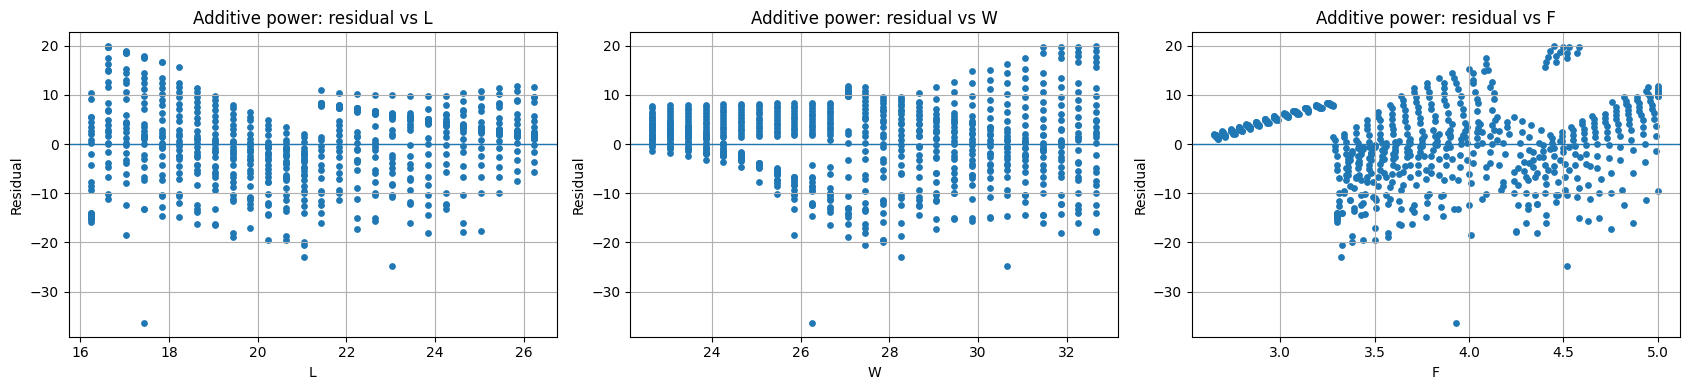

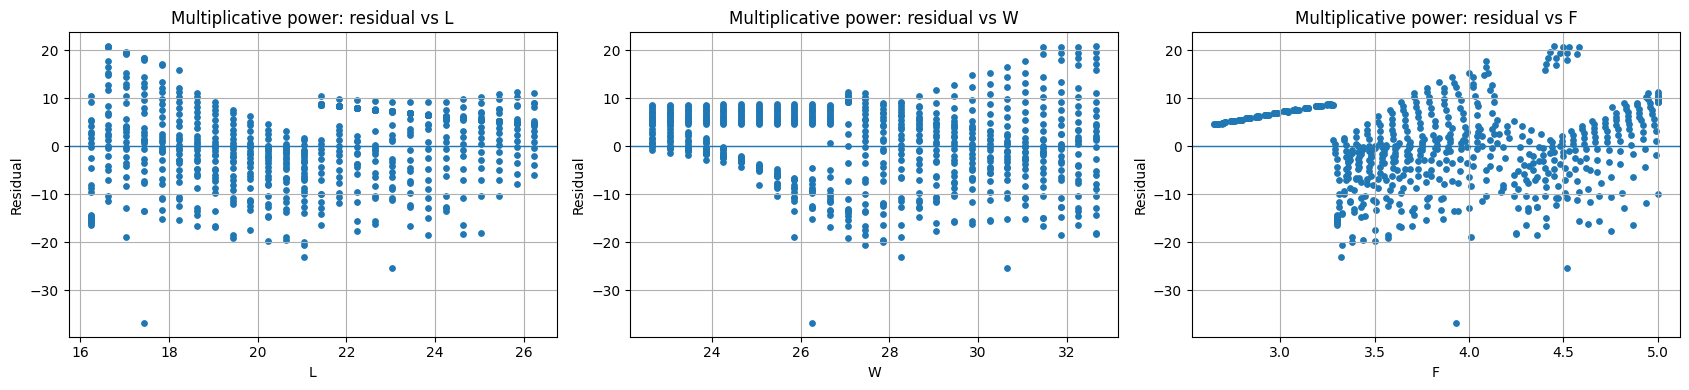

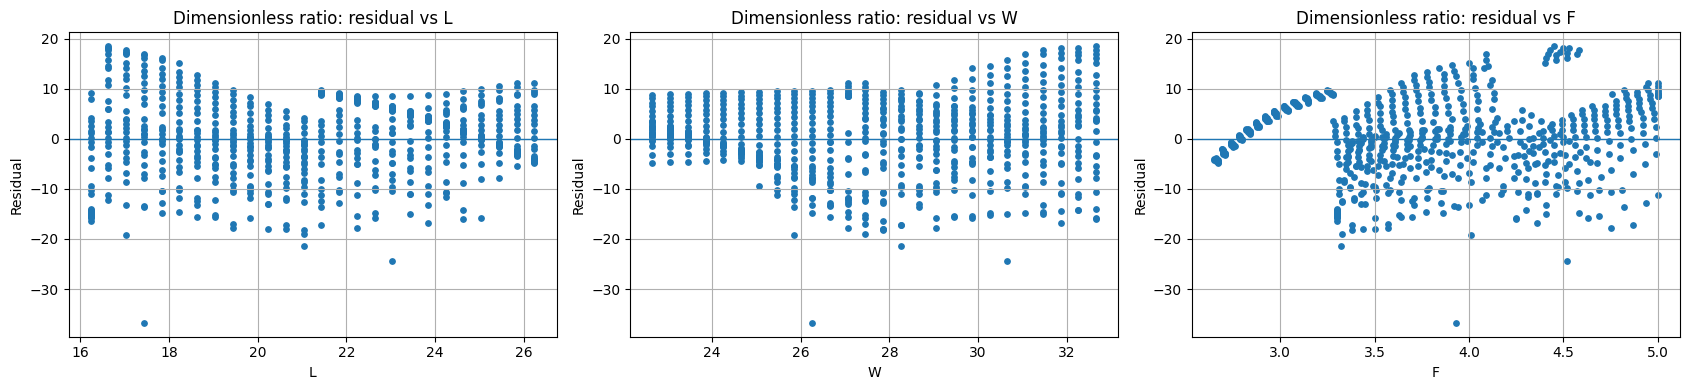

In [18]:
model_predictions = {
    "Additive power": pred_add,
    "Multiplicative power": pred_power,
    "Dimensionless ratio": pred_ratio
}

for name, prediction in model_predictions.items():
    residual = Y - prediction

    fig, axes = plt.subplots(1, 3, figsize=(17, 4))

    axes[0].scatter(L, residual, s=15)
    axes[0].axhline(0, linewidth=1)
    axes[0].set_xlabel("L")
    axes[0].set_ylabel("Residual")
    axes[0].set_title(f"{name}: residual vs L")

    axes[1].scatter(W, residual, s=15)
    axes[1].axhline(0, linewidth=1)
    axes[1].set_xlabel("W")
    axes[1].set_ylabel("Residual")
    axes[1].set_title(f"{name}: residual vs W")

    axes[2].scatter(F, residual, s=15)
    axes[2].axhline(0, linewidth=1)
    axes[2].set_xlabel("F")
    axes[2].set_ylabel("Residual")
    axes[2].set_title(f"{name}: residual vs F")

    plt.tight_layout()
    plt.show()


# 15. Current conclusion

At this stage we are **not selecting the final equation yet**.

The important findings to carry forward are:

1. The dataset contains a complete 26×26 `(L,W)` parameter grid.
2. Each `(L,W)` geometry has only one `F` value.
3. Therefore, this is not a conventional fixed-geometry frequency sweep.
4. We need to study the mathematical mapping:
   \[
   (L,W)
ightarrow F
   \]
   and then:
   \[
   (L,W,F)
ightarrow S_{11}
   \]
5. Power-law and dimensionless mathematical forms are now being tested explicitly.
6. Residual patterns will tell us what mathematical structure is still missing.

### Next stage

The next notebook section will investigate **separable and normalized mathematical forms**, including whether S11 can be represented using a small number of dimensionless groups.

That is the direction most likely to produce a genuinely useful mathematical equation rather than an arbitrary high-degree polynomial.
